# 04 - LightGBM Baseline

This notebook trains the first LightGBM model for the binary heart disease classification task and compares it with the existing baseline models.

No hyperparameter tuning is performed here. The goal is to establish a simple, readable LightGBM benchmark.

## 1. Use the Existing Train/Test Split

The preprocessing notebook already created the train/test split and saved processed files. This notebook reuses those files instead of splitting again so that LightGBM is evaluated on exactly the same held-out test set as Logistic Regression, Random Forest, and XGBoost.

Using the same split keeps the model comparison fair and avoids accidental changes to the evaluation set.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from lightgbm import LGBMClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluate import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    write_results_markdown,
)

In [2]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_DIR

WindowsPath('d:/代码集/Python/heart-disease-lightgbm/data/processed')

## 2. Load Processed Data

The feature files are already imputed and one-hot encoded. The label files contain the binary `target` column.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze("columns")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (736, 32)
X_test shape: (184, 32)
y_train shape: (736,)
y_test shape: (184,)


## 3. Validate Model-Ready Data

Before training, confirm the saved datasets are complete, numeric, and aligned. This guards against accidentally training on incomplete or non-model-ready data.

In [4]:
class_distribution = pd.DataFrame(
    {
        "y_train_count": y_train.value_counts().sort_index(),
        "y_train_proportion": y_train.value_counts(normalize=True).sort_index(),
        "y_test_count": y_test.value_counts().sort_index(),
        "y_test_proportion": y_test.value_counts(normalize=True).sort_index(),
    }
)

class_distribution

,y_train_count,y_train_proportion,y_test_count,y_test_proportion
target,,,,
0,329,0.447011,82,0.445652
1,407,0.552989,102,0.554348


In [5]:
missing_value_check = pd.Series(
    {
        "X_train_missing": int(X_train.isna().sum().sum()),
        "X_test_missing": int(X_test.isna().sum().sum()),
        "y_train_missing": int(y_train.isna().sum()),
        "y_test_missing": int(y_test.isna().sum()),
    }
)

missing_value_check

X_train_missing    0
X_test_missing     0
y_train_missing    0
y_test_missing     0
dtype: int64

In [6]:
non_numeric_columns = X_train.select_dtypes(exclude="number").columns.tolist()

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_train.columns.equals(X_test.columns)
assert (missing_value_check == 0).all(), missing_value_check
assert not non_numeric_columns, f"Non-numeric columns found: {non_numeric_columns}"

print(f"All {X_train.shape[1]} feature columns are numeric and model-ready.")

All 32 feature columns are numeric and model-ready.


## 4. Train Initial LightGBM Model

LightGBM is a gradient boosting model based on decision trees. Here it is trained with simple initial parameters only. Hyperparameter tuning is intentionally left for a later step.

In [7]:
lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
)

lightgbm_result = evaluate_model(
    "LightGBM",
    lightgbm_model,
    X_train,
    y_train,
    X_test,
    y_test,
)

lightgbm_results_df = pd.DataFrame([lightgbm_result])
lightgbm_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,LightGBM,0.842391,0.847619,0.872549,0.859903,0.927666,66,16,13,89


## 5. Compare with Existing Baselines

The existing baseline metrics are read from `reports/results.md`. Only the original baseline rows are kept, then the new LightGBM row is appended.

In heart disease prediction, recall and false negatives deserve extra attention. Recall measures how many true heart-disease cases are detected. False negatives are patients with heart disease who are incorrectly classified as low-risk.

In [8]:
def read_results_table(markdown_path):
    table_lines = [
        line.strip()
        for line in markdown_path.read_text(encoding="utf-8").splitlines()
        if line.strip().startswith("|")
    ]

    rows = []
    header = None

    for line in table_lines:
        values = [value.strip() for value in line.strip("|").split("|")]
        if all(set(value) <= {"-", ":"} for value in values):
            continue
        if header is None:
            header = values
        else:
            rows.append(values)

    results = pd.DataFrame(rows, columns=header)
    for column in results.columns:
        if column != "Model":
            results[column] = pd.to_numeric(results[column])

    return results


baseline_model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
baseline_results_df = read_results_table(REPORTS_DIR / "results.md")
baseline_results_df = baseline_results_df[
    baseline_results_df["Model"].isin(baseline_model_names)
].copy()

comparison_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "True Negatives",
    "False Positives",
    "False Negatives",
    "True Positives",
]

comparison_df = pd.concat(
    [baseline_results_df[comparison_columns], lightgbm_results_df[comparison_columns]],
    ignore_index=True,
)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,0.842000,0.835000,0.892000,0.863000,0.926000,64,18,11,91
1,Random Forest,0.848000,0.849000,0.882000,0.865000,0.928000,66,16,12,90
2,XGBoost,0.859000,0.852000,0.902000,0.876000,0.901000,66,16,10,92
3,LightGBM,0.842391,0.847619,0.872549,0.859903,0.927666,66,16,13,89


In [9]:
comparison_df.sort_values(
    ["Recall", "False Negatives", "ROC-AUC"],
    ascending=[False, True, False],
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,XGBoost,0.859000,0.852000,0.902000,0.876000,0.901000,66,16,10,92
1,Logistic Regression,0.842000,0.835000,0.892000,0.863000,0.926000,64,18,11,91
2,Random Forest,0.848000,0.849000,0.882000,0.865000,0.928000,66,16,12,90
3,LightGBM,0.842391,0.847619,0.872549,0.859903,0.927666,66,16,13,89


## 6. Save Updated Results and Figures

The combined comparison is written back to `reports/results.md`. LightGBM-specific confusion matrix, ROC curve, and feature importance figures are saved to `reports/figures/`.

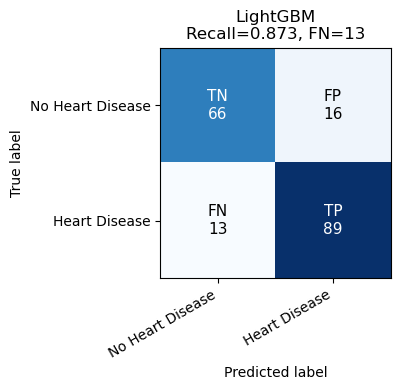

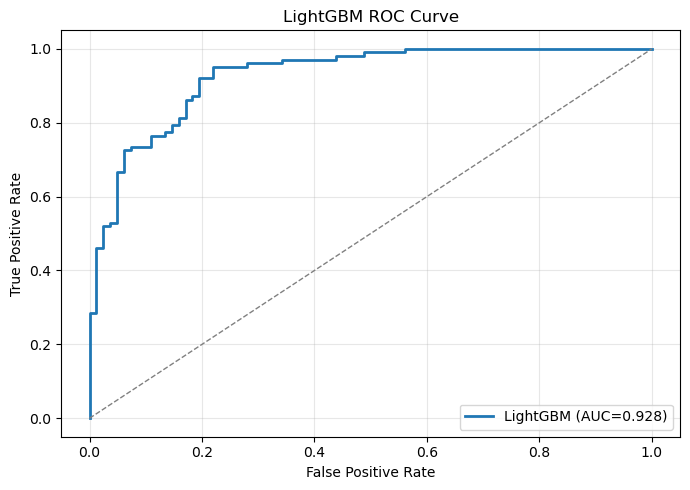

In [10]:
write_results_markdown(
    comparison_df,
    REPORTS_DIR / "results.md",
    title="Model Comparison Results",
    model_group_name="baseline models and LightGBM",
    best_model_label="model",
)

lightgbm_models = {"LightGBM": lightgbm_model}

confusion_fig, _ = plot_confusion_matrix(
    lightgbm_models,
    X_test,
    y_test,
    save_path=FIGURES_DIR / "lightgbm_confusion_matrix.png",
)

roc_fig, _ = plot_roc_curve(
    lightgbm_models,
    X_test,
    y_test,
    save_path=FIGURES_DIR / "lightgbm_roc_curve.png",
    title="LightGBM ROC Curve",
)

## 7. Feature Importance

LightGBM exposes feature importance from the fitted tree ensemble. These values show which processed features were used most often or most strongly by the model.

Because the categorical variables were one-hot encoded during preprocessing, many feature names represent individual category indicators.

,Feature,Importance
2,num__chol,536
3,num__thalch,444
0,num__age,389
1,num__trestbps,262
4,num__oldpeak,242
23,cat__slope_flat,74
9,cat__dataset_Switzerland,68
25,cat__ca_0.0,64
12,cat__cp_atypical angina,63
18,cat__restecg_normal,60


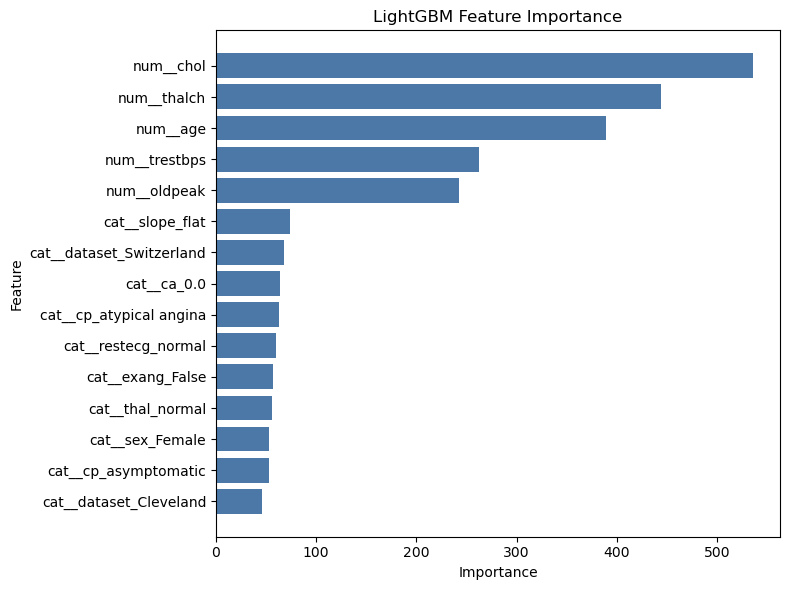

In [11]:
feature_importance_df = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": lightgbm_model.feature_importances_,
    }
).sort_values("Importance", ascending=False)

top_features = feature_importance_df.head(15).sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features["Feature"], top_features["Importance"], color="#4C78A8")
ax.set_title("LightGBM Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lightgbm_feature_importance.png", dpi=150, bbox_inches="tight")

feature_importance_df.head(15)

## 8. Interpretation

On this first untuned run, LightGBM reaches accuracy `0.842`, recall `0.873`, F1 `0.860`, and ROC-AUC `0.928` on the existing test set.

Its ROC-AUC is competitive with Random Forest and Logistic Regression, but its recall is lower than Logistic Regression and XGBoost. It produces `13` false negatives, compared with `11` for Logistic Regression, `12` for Random Forest, and `10` for XGBoost. For medical screening, this matters because false negatives are patients with heart disease who are incorrectly classified as low-risk.

The top LightGBM features in this run include cholesterol, maximum heart rate, age, resting blood pressure, ST depression, slope, dataset indicators, ca, chest pain category, and resting ECG category. These suggest that both continuous clinical measurements and encoded categorical clinical findings are contributing to the model.

SHAP analysis is intentionally not included here and remains a future interpretability step.